# Part 0 - Loads and Helper Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import ParameterSampler

from sklearn.metrics import ndcg_score
from sklearn.preprocessing import StandardScaler

from pathlib import Path
from datetime import datetime

## Global Configurations

In [2]:
# Reproducibility
SEED = 42

# Paths
TRAIN_PATH = "../data/training_set_VU_DM.csv"
TEST_PATH = "../data/test_set_VU_DM.csv"

# Target engineering
BOOKING_RELEVANCE = 5
CLICK_RELEVANCE = 1
TARGET_COL = "target"

# Validation split
TEST_SIZE = 0.2

# Ranking evaluation
NDCG_AT = 5


# Columns to remove from features
LEAKAGE_COLS = [
    "target",
    "booking_bool",
    "click_bool",
    "gross_bookings_usd",
    "position",
]

ID_COLS = [
    "srch_id",
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "prop_id",
    "srch_destination_id",
]

DATE_COLS = [
    "date_time",
    "date",
]

SCALE_COLS = [

    "price_usd_log",
    "srch_booking_window_log",
    "prop_location_score2_log",
    "orig_destination_distance_log",
    "visitor_hist_adr_usd_log",

    "prop_review_score",
    "srch_query_affinity_score",
    "visitor_hist_starrating"

]

DROP_COLS = LEAKAGE_COLS + ID_COLS + DATE_COLS

## Defining Columns and Data Types

In [4]:
cont_cols = [
    'visitor_hist_starrating',
    'visitor_hist_adr_usd',
    'prop_review_score',
    'prop_location_score1',
    'prop_location_score2',
    'prop_log_historical_price',
    'price_usd',
    'srch_query_affinity_score',
    'orig_destination_distance',
    'gross_bookings_usd',
    'comp1_rate_percent_diff',
    'comp2_rate_percent_diff',
    'comp3_rate_percent_diff',
    'comp4_rate_percent_diff',
    'comp5_rate_percent_diff',
    'comp6_rate_percent_diff',
    'comp7_rate_percent_diff',
    'comp8_rate_percent_diff'
]

bool_cols = [
    'prop_brand_bool',
    'promotion_flag',
    'srch_saturday_night_bool',
    'random_bool',
    'click_bool',
    'booking_bool'
]

id_cols = [
    'srch_id',
    'site_id',
    'visitor_location_country_id',
    'prop_country_id',
    'prop_id',
    'srch_destination_id'
]

cat_cols = [
    'comp1_rate', 'comp1_inv',
    'comp2_rate', 'comp2_inv',
    'comp3_rate', 'comp3_inv',
    'comp4_rate', 'comp4_inv',
    'comp5_rate', 'comp5_inv',
    'comp6_rate', 'comp6_inv',
    'comp7_rate', 'comp7_inv',
    'comp8_rate', 'comp8_inv'
]

int_cols = [
    'prop_starrating',
    'position',
    'srch_length_of_stay',
    'srch_booking_window',
    'srch_adults_count',
    'srch_children_count',
    'srch_room_count'
]

In [5]:
dtype_dict = {}

# float columns
for col in cont_cols:
    dtype_dict[col] = 'float32'

# bool columns
for col in bool_cols:
    dtype_dict[col] = 'bool'

# id columns
for col in id_cols:
    dtype_dict[col] = 'int32'

# categorical columns
for col in cat_cols:
    dtype_dict[col] = 'int8'

# small integer columns
for col in int_cols:
    dtype_dict[col] = 'int8'

## Helper Functions

### Loading

In [6]:
# Load Training Data
def load_train_data(
    path,
    booking_relevance=5,
    click_relevance=1
):

    df = pd.read_csv(
        path,
        dtype=dtype_dict,
        low_memory=True
    )

    # Create Target
    df["target"] = (
        booking_relevance * df["booking_bool"].astype("int8") +
        click_relevance * df["click_bool"].astype("int8")
    ).astype("int8")

    return df

In [7]:
# Load Testing Data
def load_test_data(path):

    df = pd.read_csv(
        path,
        dtype=dtype_dict,
        low_memory=True
    )

    return df

### Preprocessing

In [8]:
# Stateless Prepocess Function (applied before Train-Val split)
def stateless_preprocess(
    df,
    comp_rate_diff_upper_limit=150
):

    df = df.copy()

    # ==================================================
    # DATE PARSING
    # ==================================================

    df["date_time"] = pd.to_datetime(df["date_time"])

    # ==================================================
    # WRONG VALUE HANDLING
    # ==================================================

    # Negative booking windows are invalid
    df["srch_booking_window"] = (
        df["srch_booking_window"]
        .clip(lower=0)
    )

    # ==================================================
    # OUTLIER CAPPING
    # ==================================================

    # Cap extreme competitor rate differences
    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        df[col] = (
            df[col]
            .clip(upper=comp_rate_diff_upper_limit)
        )

    # ==================================================
    # SEMANTIC MISSING VALUES -> NaN
    # ==================================================

    # Unknown starrating
    df["prop_starrating"] = (
        df["prop_starrating"]
        .replace(0, np.nan)
    )

    # Unknown historical price
    df["prop_log_historical_price"] = (
        df["prop_log_historical_price"]
        .replace(0, np.nan)
    )

    # Unknown review score
    df["prop_review_score"] = (
        df["prop_review_score"]
        .replace(0, np.nan)
    )


    return df

In [9]:
# ==================================================
# FIT LEARNED PREPROCESSING (SVD VERSION)
# ==================================================
def fit_learned_preprocessing(
    train_df,
    price_usd_quantile=0.995,
    booking_window_quantile=0.995,
    comp_rate_diff_upper_limit=150
):

    stats = {}

    # ==================================================
    # OUTLIER CAPS
    # ==================================================

    stats["price_usd_upper_cap"] = (
        train_df["price_usd"]
        .quantile(price_usd_quantile)
    )

    stats["srch_booking_window_upper_cap"] = (
        train_df["srch_booking_window"]
        .quantile(booking_window_quantile)
    )

    stats["comp_rate_diff_upper_cap"] = (
        comp_rate_diff_upper_limit
    )

    # ==================================================
    # GLOBAL IMPUTATION VALUES
    # ==================================================

    stats["prop_starrating_mode"] = (
        train_df["prop_starrating"]
        .mode()[0]
    )

    stats["prop_log_historical_price_median"] = (
        train_df["prop_log_historical_price"]
        .median()
    )

    stats["prop_review_score_median"] = (
        train_df["prop_review_score"]
        .median()
    )

    stats["prop_location_score2_median"] = (
        train_df["prop_location_score2"]
        .median()
    )

    stats["orig_destination_distance_median"] = (
        train_df["orig_destination_distance"]
        .median()
    )

    stats["srch_query_affinity_score_median"] = (
        train_df["srch_query_affinity_score"]
        .median()
    )

    stats["visitor_hist_starrating_median"] = (
        train_df["visitor_hist_starrating"]
        .median()
    )

    stats["visitor_hist_adr_usd_median"] = (
        train_df["visitor_hist_adr_usd"]
        .median()
    )

    # ==================================================
    # COMPETITOR FEATURES
    # ==================================================

    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        stats[f"{col}_median"] = (
            train_df[col]
            .median()
        )

    return stats

In [10]:
# ==================================================
# APPLY LEARNED PREPROCESSING (SVD VERSION)
# ==================================================
def apply_learned_preprocessing(
    df,
    stats
):

    df = df.copy()

    # ==================================================
    # PRICE USD
    # ==================================================

    df["price_usd"] = (
        df["price_usd"]
        .clip(upper=stats["price_usd_upper_cap"])
        .astype("float32")
    )

    df["price_usd_log"] = (
        np.log1p(df["price_usd"])
        .astype("float32")
    )

    # ==================================================
    # SEARCH BOOKING WINDOW
    # ==================================================

    df["srch_booking_window"] = (
        df["srch_booking_window"]
        .clip(
            upper=stats["srch_booking_window_upper_cap"]
        )
        .astype("float32")
    )

    df["srch_booking_window_log"] = (
        np.log1p(df["srch_booking_window"])
        .astype("float32")
    )

    # ==================================================
    # PROPERTY FEATURES
    # ==================================================

    df["prop_starrating"] = (
        df["prop_starrating"]
        .fillna(stats["prop_starrating_mode"])
        .astype("float32")
    )

    df["prop_log_historical_price"] = (
        df["prop_log_historical_price"]
        .fillna(
            stats["prop_log_historical_price_median"]
        )
        .astype("float32")
    )

    df["prop_review_score"] = (
        df["prop_review_score"]
        .fillna(stats["prop_review_score_median"])
        .astype("float32")
    )

    df["prop_location_score2"] = (
        df["prop_location_score2"]
        .fillna(stats["prop_location_score2_median"])
        .astype("float32")
    )

    df["prop_location_score2_log"] = (
        np.log1p(df["prop_location_score2"])
        .astype("float32")
    )

    # ==================================================
    # DESTINATION DISTANCE
    # ==================================================

    df["orig_destination_distance"] = (
        df["orig_destination_distance"]
        .fillna(
            stats["orig_destination_distance_median"]
        )
        .astype("float32")
    )

    df["orig_destination_distance_log"] = (
        np.log1p(df["orig_destination_distance"])
        .astype("float32")
    )

    # ==================================================
    # SEARCH QUERY AFFINITY
    # ==================================================

    df["srch_query_affinity_score"] = (
        df["srch_query_affinity_score"]
        .fillna(
            stats["srch_query_affinity_score_median"]
        )
        .astype("float32")
    )

    # ==================================================
    # VISITOR HISTORY FEATURES
    # ==================================================

    df["visitor_hist_starrating"] = (
        df["visitor_hist_starrating"]
        .fillna(
            stats["visitor_hist_starrating_median"]
        )
        .astype("float32")
    )

    df["visitor_hist_adr_usd"] = (
        df["visitor_hist_adr_usd"]
        .fillna(
            stats["visitor_hist_adr_usd_median"]
        )
        .astype("float32")
    )

    df["visitor_hist_adr_usd_log"] = (
        np.log1p(df["visitor_hist_adr_usd"])
        .astype("float32")
    )

    # ==================================================
    # COMPETITOR FEATURES
    # ==================================================

    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        df[col] = (
            df[col]
            .clip(
                upper=stats["comp_rate_diff_upper_cap"]
            )
            .fillna(stats[f"{col}_median"])
            .astype("float32")
        )

        df[f"{col}_log"] = (
            np.log1p(df[col])
            .astype("float32")
        )

    return df

In [ ]:
# ==================================================
# FIT SCALER
# ==================================================

def fit_scaler(
    train_df,
    scale_cols
):

    scaler = StandardScaler()

    scaler.fit(
        train_df[scale_cols]
    )

    return scaler

In [ ]:
# ==================================================
# APPLY SCALER
# ==================================================

def apply_scaler(
    df,
    scaler,
    scale_cols
):

    df = df.copy()

    df[scale_cols] = scaler.transform(
        df[scale_cols]
    )

    return df

### Train-Validation Split

In [11]:
# Train-Val Split Function
def train_val_split(
    df,
    group_col="srch_id",
    test_size=0.2,
    random_state=42
):

    splitter = GroupShuffleSplit(
        test_size=test_size,
        n_splits=1,
        random_state=random_state
    )

    train_idx, val_idx = next(
        splitter.split(
            df,
            groups=df[group_col]
        )
    )

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    return train_df, val_df

### Modeling

In [20]:
# ==================================================
# CREATE INTERACTION MATRIX
# ==================================================
def create_interaction_matrix(
    df,
    user_col="srch_id",
    item_col="prop_id",
    target_col="target"
):

    interaction_df = df[[

        user_col,
        item_col,
        target_col

    ]].copy()

    interaction_df.columns = [

        "user",
        "item",
        "rating"

    ]

    return interaction_df

### Training

### Evaluation

In [22]:
# Evaluation Function
def evaluate_ndcg(
    model,
    X,
    y,
    df,
    group_col="srch_id",
    target_col="target",
    k=NDCG_AT
):

    # ==================================================
    # PREDICT
    # ==================================================

    preds = model.predict(X)

    # ==================================================
    # CREATE EVALUATION DATAFRAME
    # ==================================================

    eval_df = df[[group_col]].copy()

    eval_df[target_col] = y.values
    eval_df["pred_score"] = preds

    # ==================================================
    # SORT PREDICTIONS WITHIN GROUP
    # ==================================================

    eval_df = eval_df.sort_values(
        [group_col, "pred_score"],
        ascending=[True, False]
    )

    # ==================================================
    # COMPUTE NDCG@K
    # ==================================================

    ndcg_scores = []

    for _, group in eval_df.groupby(group_col):

        true_relevance = (
            group[target_col]
            .values
        )

        pred_scores = (
            group["pred_score"]
            .values
        )

        ndcg = ndcg_score(
            [true_relevance],
            [pred_scores],
            k=k
        )

        ndcg_scores.append(ndcg)

    mean_ndcg = np.mean(ndcg_scores)

    # ==================================================
    # PRINT RESULT
    # ==================================================

    print(f"NDCG@{k}: {mean_ndcg:.5f}")

    return mean_ndcg

In [24]:
# =========================================================
# TOP-K BOOKING / CLICK RETRIEVAL EVALUATION
# =========================================================
def evaluate_topk_behavior(
    model,
    X,
    df,
    max_k=5
):

    eval_df = df.copy()

    # -----------------------------------------------------
    # Predictions
    # -----------------------------------------------------

    eval_df["prediction"] = model.predict(X)

    # Sort by prediction within search
    eval_df = (
        eval_df.sort_values(
            ["srch_id", "prediction"],
            ascending=[True, False]
        )
    )

    # Rank predictions
    eval_df["pred_rank"] = (
        eval_df.groupby("srch_id")
        .cumcount() + 1
    )

    # -----------------------------------------------------
    # BOOKING SEARCHES
    # -----------------------------------------------------

    booking_searches = (
        eval_df.groupby("srch_id")["booking_bool"]
        .sum()
    )

    booking_search_ids = (
        booking_searches[booking_searches > 0]
        .index
    )

    booking_df = (
        eval_df[
            eval_df["srch_id"].isin(booking_search_ids)
        ]
    )

    booking_topk = []

    for k in range(1, max_k + 1):

        topk_df = (
            booking_df[
                booking_df["pred_rank"] <= k
            ]
        )

        success = (
            topk_df.groupby("srch_id")["booking_bool"]
            .max()
            .mean()
        )

        booking_topk.append(success * 100)

    # -----------------------------------------------------
    # CLICK-ONLY SEARCHES
    # -----------------------------------------------------

    search_booking = (
        eval_df.groupby("srch_id")["booking_bool"]
        .sum()
    )

    click_search_ids = (
        search_booking[search_booking == 0]
        .index
    )

    click_df = (
        eval_df[
            eval_df["srch_id"].isin(click_search_ids)
        ]
    )

    click_topk = []

    for k in range(1, max_k + 1):

        topk_df = (
            click_df[
                click_df["pred_rank"] <= k
            ]
        )

        success = (
            topk_df.groupby("srch_id")["click_bool"]
            .max()
            .mean()
        )

        click_topk.append(success * 100)

    # -----------------------------------------------------
    # PLOTS
    # -----------------------------------------------------

    ks = np.arange(1, max_k + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Booking plot
    bars1 = axes[0].bar(ks, booking_topk)

    axes[0].set_title("Booked Hotel Retrieved in Top-K")
    axes[0].set_xlabel("K")
    axes[0].set_ylabel("Probability (%)")
    axes[0].set_xticks(ks)

    for bar, value in zip(bars1, booking_topk):

        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    # Click plot
    bars2 = axes[1].bar(ks, click_topk)

    axes[1].set_title("Clicked Hotel Retrieved in Top-K\n(No Booking Searches)")
    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Probability (%)")
    axes[1].set_xticks(ks)

    for bar, value in zip(bars2, click_topk):

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

## Load Datasets

In [25]:
#  ========== Load Training Data ==========
train_df = load_train_data(
    TRAIN_PATH,
    booking_relevance=5,
    click_relevance=1
)
print(f"Shape of training set: {train_df.shape}")
train_df.dtypes

Shape of training set: (4958347, 55)


srch_id                           int32
date_time                        object
site_id                           int32
visitor_location_country_id       int32
visitor_hist_starrating         float32
visitor_hist_adr_usd            float32
prop_country_id                   int32
prop_id                           int32
prop_starrating                    int8
prop_review_score               float32
prop_brand_bool                    bool
prop_location_score1            float32
prop_location_score2            float32
prop_log_historical_price       float32
position                           int8
price_usd                       float32
promotion_flag                     bool
srch_destination_id               int32
srch_length_of_stay                int8
srch_booking_window                int8
srch_adults_count                  int8
srch_children_count                int8
srch_room_count                    int8
srch_saturday_night_bool           bool
srch_query_affinity_score       float32


# Part 1 - Preprocessing for Train, Validation, Test Sets

In [26]:
# ==================================================
# STATELESS PREPROCESSING
# ==================================================

train_df = stateless_preprocess(train_df)

# ==================================================
# TRAIN / VALIDATION SPLIT
# ==================================================

train_df, val_df = train_val_split(
    train_df,
    group_col="srch_id",
    test_size=TEST_SIZE,
    random_state=SEED
)

# ==================================================
# FIT LEARNED PREPROCESSING
# ==================================================

preprocessing_stats = fit_learned_preprocessing(
    train_df,
    price_usd_quantile=0.995
)

# ==================================================
# APPLY LEARNED PREPROCESSING
# ==================================================

train_df = apply_learned_preprocessing(
    train_df,
    preprocessing_stats
)

val_df = apply_learned_preprocessing(
    val_df,
    preprocessing_stats
)

# ==================================================
# SCALING
# ==================================================

scaler = fit_scaler(
    train_df,
    scale_cols
)

train_df = apply_scaler(
    train_df,
    scaler,
    scale_cols
)

val_df = apply_scaler(
    val_df,
    scaler,
    scale_cols
)

In [ ]:
# ==================================================
# CREATE INTERACTION MATRICES
# ==================================================

train_interactions = create_interaction_matrix(
    train_df
)

val_interactions = create_interaction_matrix(
    val_df
)

### Verifying Preprocessing

In [27]:
# ==================================================
# VERIFY SHAPES
# ==================================================

print("========== SHAPES ==========")

print(f"Train shape:      {train_interactions.shape}")
print(f"Validation shape: {val_interactions.shape}")

train_interactions.head()

========== SHAPES ==========
Train shape:      (3966682, 105)
Validation shape: (991665, 105)

========== TRAIN NaNs ==========
gross_bookings_usd    3855821
dtype: int64

========== VALIDATION NaNs ==========
gross_bookings_usd    964136
dtype: int64


# Part 2 - Modeling

### 2.2 Training

In [29]:
# ==================================================
# TRAIN SVD Model
# ==================================================




Training LambdaMART...


C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 10083
[LightGBM] [Info] Number of data points i

### 2.3 Evaluation

In [31]:
'''# =========================================================
# EVALUATION ON TRAIN
# =========================================================

train_ndcg5 = evaluate_ndcg(
    model=lgb_ranker,
    X=X_train,
    y=y_train,
    df=train_df,
    group_col="srch_id",
    target_col=TARGET_COL,
    k=NDCG_AT
)

print(f"Train NDCG@5: {train_ndcg5:.5f}")


# =========================================================
# EVALUATION ON VALIDATION
# =========================================================

val_ndcg5 = evaluate_ndcg(
    model=lgb_ranker,
    X=X_val,
    y=y_val,
    df=val_df,
    group_col="srch_id",
    target_col=TARGET_COL,
    k=NDCG_AT
)

print(f"Validation NDCG@5: {val_ndcg5:.5f}")'''

C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
NDCG@5: 0.51196
Train NDCG@5: 0.51196


C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
NDCG@5: 0.39884
Validation NDCG@5: 0.39884


C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


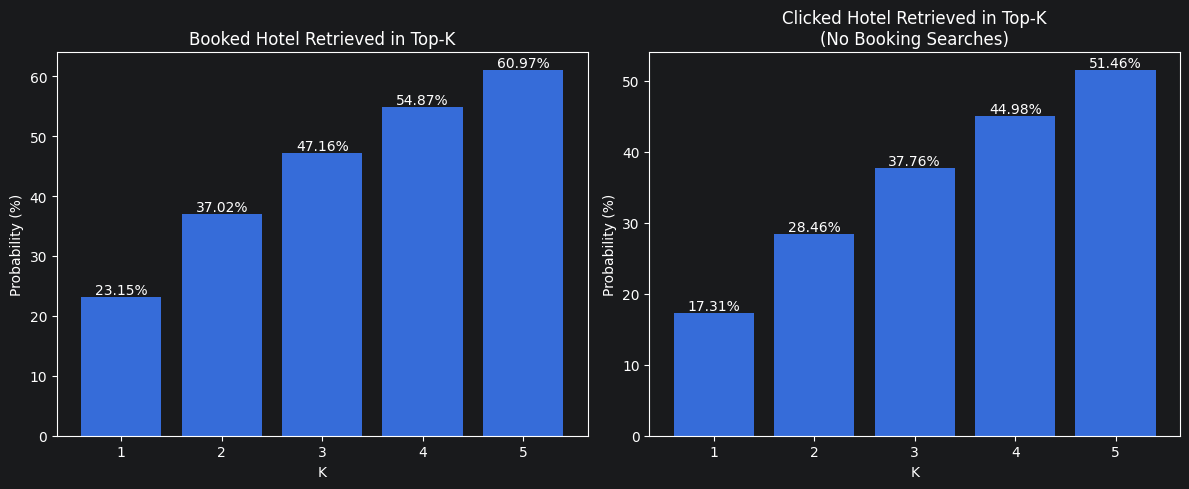

In [32]:
'''# =========================================================
# EVALUATION of TopK Behavior
# =========================================================

evaluate_topk_behavior(
    model=lgb_ranker,
    X=X_val,
    df=val_df
)'''